Reinforcement Learning (RL) is a branch of Machine Learning where an agent learns to make decisions by interacting with an environment. Unlike supervised learning, reinforcement learning does not require labeled data. Instead, the agent learns through rewards and penalties.

In this project, we train an intelligent agent to solve the Lunar Lander environment provided by Gymnasium. The objective of the agent is to land a spacecraft safely on a landing pad while minimizing fuel consumption and avoiding crashes.

The PPO (Proximal Policy Optimization) algorithm from Stable-Baselines3 is used because it is one of the most stable and widely used reinforcement learning algorithms.

In [ ]:
!pip install gymnasium[box2d]
!pip install stable-baselines3[extra]
!pip install moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.7 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("LunarLander-v3")

print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)

Action Space:
Discrete(4)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [ ]:
observation, info = env.reset()

print("Initial Observation:")
print(observation)

Initial Observation:
[-0.00597134  1.4210308  -0.6048471   0.44933745  0.00692608  0.13700691
  0.          0.        ]


In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

observation, info = env.reset()

for i in range(100):

    action = env.action_space.sample()

    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        observation, info = env.reset()

env.close()

print("Random actions executed successfully!")

Random actions executed successfully!


In [ ]:
env = Monitor(gym.make("LunarLander-v3"))

In [ ]:
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.0003,
    gamma=0.99,
    batch_size=64
)

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
model.learn(total_timesteps=100000)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 104      |
|    ep_rew_mean     | -209     |
| time/              |          |
|    fps             | 1162     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 102          |
|    ep_rew_mean          | -195         |
| time/                   |              |
|    fps                  | 875          |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0071158684 |
|    clip_fraction        | 0.00879      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    explained_variance   | -0.0103      |
|    learning_r

In [ ]:
model.save("ppo_lunarlander")

In [ ]:
model = PPO.load("ppo_lunarlander")

In [ ]:
mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=10
)

print("Mean Reward:", mean_reward)
print("Standard Deviation:", std_reward)

Mean Reward: -92.1932059
Standard Deviation: 16.130688715951635


In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

observation, info = env.reset()

for _ in range(1000):

    action, _ = model.predict(observation, deterministic=True)

    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        break

env.close()

print("Episode finished.")

Episode finished.


In [ ]:
from gymnasium.wrappers import RecordVideo

env = RecordVideo(
    gym.make("LunarLander-v3", render_mode="rgb_array"),
    video_folder="videos",
    episode_trigger=lambda x: True
)

observation, info = env.reset()

done = False

while not done:

    action, _ = model.predict(observation, deterministic=True)

    observation, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

env.close()

print("Video saved!")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Video saved!


In [ ]:
import os
from IPython.display import Video

video_path = "videos"

files = os.listdir(video_path)

Video(os.path.join(video_path, files[-1]), embed=True)

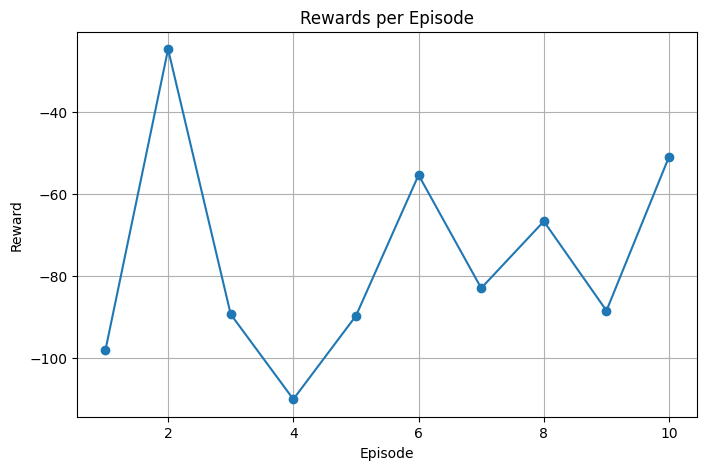

In [ ]:
episodes = np.arange(1, 11)

rewards = []

for _ in range(10):

    obs, info = env.reset()

    done = False

    total_reward = 0

    while not done:

        action, _ = model.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards.append(total_reward)

plt.figure(figsize=(8,5))
plt.plot(episodes, rewards, marker='o')
plt.title("Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

##Conclusion
This project successfully demonstrates how reinforcement learning can be applied to solve the Lunar Lander task. The PPO algorithm was used to train an intelligent agent capable of learning optimal landing strategies through trial and error. Over time, the agent improved its policy by maximizing cumulative rewards, resulting in safer and more efficient landings. This project highlights the effectiveness of modern reinforcement learning techniques for solving sequential decision-making problems in simulated environments.